#### ◆ Library imports

In [5]:
import re
import json
import unicodedata
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

#### ◆ Loading the datasets for analysis
- MC joint text restoration dataset
- MorisienMT
- KreolMT

In [6]:
joint_text_restoration_dataset_path = (
    r"C:\Users\ae\OneDrive\thesis\data\data_versions\mc_joint_text_restoration.json"
)

morisien_mt_jsonl_dataset_path = (
    r"C:\Users\ae\OneDrive\thesis\research_question_1\morisien-mt-en-cr.jsonl"
)

kreol_mt_parquet_dataset_path = (
    r"C:\Users\ae\OneDrive\thesis\research_question_1\kreol-mt.parquet"
)

def load_joint_text_restoration_dataset(file_path):
    """
    Load Mauritian Creole joint text restoration dataset.
    
    Format:
    JSON
    
    Returns:
        DataFrame containing the joint normalization dataset.
    """

    with open(file_path, "r", encoding="utf-8") as file:
        joint_text_restoration_data = json.load(file)

    joint_text_restoration_dataframe = pd.DataFrame(
        joint_text_restoration_data
    )

    return joint_text_restoration_dataframe

def load_kreol_mt_dataset(file_path):

    kreol_mt_data = []

    with open(file_path, "r", encoding="utf-8", errors="replace") as file:
        for line in file:
            kreol_mt_data.append(json.loads(line))

    kreol_mt_dataframe = pd.DataFrame(kreol_mt_data)

    kreol_mt_dataframe = kreol_mt_dataframe.rename(
        columns={
            "input": "source_text",
            "target": "target_text"
        }
    )

    return kreol_mt_dataframe

def load_morisien_mt_dataset(file_path):
    """
    Load Morisien-MT English-Creole dataset.
    
    Format:
    Parquet
    
    Returns:
        DataFrame containing Morisien-MT data.
    """

    morisien_mt_dataframe = pd.read_parquet(file_path)

    return morisien_mt_dataframe

mc_joint_text_restoration_df = load_joint_text_restoration_dataset(
    joint_text_restoration_dataset_path
)

morisien_mt_df = load_kreol_mt_dataset(
    morisien_mt_jsonl_dataset_path
)

kreol_mt_df = load_morisien_mt_dataset(
    kreol_mt_parquet_dataset_path
)

In [9]:
# First 10 rows of MC Joint Text Restoration dataset
print("===== MC Joint Text Restoration Dataset =====")
display(mc_joint_text_restoration_df.head(10))


# First 10 rows of Morisien-MT JSONL dataset
print("===== Morisien-MT Dataset =====")
display(morisien_mt_df.head(10))


# First 10 rows of Kreol-MT Parquet dataset
kreol_mt_df = pd.json_normalize(
    kreol_mt_df["translation"]
)

# Display first 10 rows
display(kreol_mt_df.head(10))


===== MC Joint Text Restoration Dataset =====


,id,text,standardized
0,1,T penc nu p ekute tw😊,To pense nu pe ekut twa?😊
1,2,"[NAME], 2026 cpv encore ena dimoune sauvage co...","[NAME], 2026 kapav encore ena dimunn sauvage c..."
2,3,Les banla trace zot lavi boss... Zot ena 1 fam...,Les banla trasse zot lavi boss... Zot ena 1 fa...
3,4,Pas ti dire transport pou gratis,Pas ti dire transport pu gratis?
4,5,Eski sa mesure la li kadre avec promesse ki ti...,Eski sa mesure la li kadre avec promesse ki ti...
5,6,Louche sa don bon version,"Louche sa, donne bon version."
6,7,Merci chacha mo bien satisfait 😅,"Merci chacha, mo bien satisfe. 😅"
7,8,Check suicidal signs..-#joana so ban mediants?...,Check suicidal signs..-#Joana so bann mediants...
8,9,Ezoto 😂😂,Ezoto. 😂😂
9,10,Ki la bank ena dans souillac,Ki labank ena dans Souillac?


===== Morisien-MT Dataset =====


,source_text,target_text
0,to determine the thickness and dynamics of the...,pou determinn lepeser ek mouvman so lakok glas...
1,characterize the surface geology of Europa in ...,karakteriz zeolozi Europa en detay.
2,a science definition team NASA report has repo...,Enn lekip definision siens NASA finn raporte.
3,in a new study in the journal Astrobiology.,dan enn nouvo letid dan zournal Astrobiolozi.
4,If one day humans send a robotic lander to the...,Si enn jour imem envway enn robo lor sirfas Eu...
5,"study lead author Robert Pappalardo, of NASA's...","Oter prinsipal Rober Pappalardo, depi NASA so ..."
6,Pappalardo added.,Pappalardo ti azoute.
7,There is still a lot of preparation that is ne...,Ena touzour boukou preparasion ki bizin avan.
8,we could land on Europa.,nou kapav poz lor Europa.
9,but studies like these will help us focus.,me letid koumsa pou ed nou donn nou latension.


,src_lang,src_text,tgt_lang,tgt_text
0,mfe,administrasion.,eng,administration.
1,mfe,Tifrer sap bann granfrer.,eng,Younger brother rescues older brothers.
2,mfe,"Gardien la kontinie gout depi kalbas la, ziska...",eng,"The caretaker kept tasting from the gourd, unt..."
3,mfe,Nerolog.,eng,Neurologist.
4,mfe,Normal.,eng,Normal.
5,mfe,Kopirayt.,eng,Copyright.
6,mfe,Depi kot ou ete?,eng,Where are you from?
7,mfe,sosial.,eng,social.
8,mfe,Drolman.,eng,Oddly.
9,mfe,"Ler u pe diskit li, u pu truve ki li pu anrisi...",eng,"In the process of being discussed, you will fi..."


In [10]:
print("MC Joint Text Restoration columns:")
print(mc_joint_text_restoration_df.columns.tolist())

print("\nMorisien-MT columns:")
print(morisien_mt_df.columns.tolist())

print("\nKreol-MT columns:")
print(kreol_mt_df.columns.tolist())

MC Joint Text Restoration columns:
['id', 'text', 'standardized']

Morisien-MT columns:
['source_text', 'target_text']

Kreol-MT columns:
['src_lang', 'src_text', 'tgt_lang', 'tgt_text']


#### ◆ Lexical comparison analysis

##### ◆◆ Lexical similarity - [1] Jaccard index

===== JACCARD SIMILARITY MATRIX =====


,Facebook corpus,Morisien-MT,Kreol-MT
Facebook corpus,1.000000,0.080910,0.081564
Morisien-MT,0.080910,1.000000,0.896038
Kreol-MT,0.081564,0.896038,1.000000


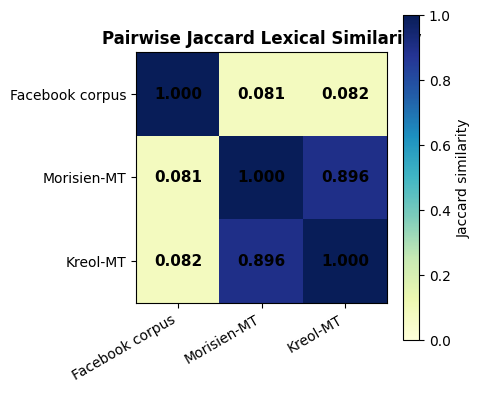

In [57]:
# ============================================================
# JACCARD LEXICAL SIMILARITY ANALYSIS
# Comparing Facebook Corpus, Morisien-MT and Kreol-MT
# ============================================================

# ============================================================
# 1. TEXT NORMALIZATION
# ============================================================

def normalize_text(text):
    """
    Normalize text before lexical analysis.
    """

    if pd.isna(text):
        return ""

    text = str(text)

    # Unicode normalization
    text = unicodedata.normalize(
        "NFKC",
        text
    )

    # Lowercase
    text = text.casefold()

    # Normalize apostrophes
    text = text.replace("’", "'")
    text = text.replace("‘", "'")

    # Remove URLs
    text = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        text
    )

    # Remove emails
    text = re.sub(
        r"\S+@\S+\.\S+",
        " ",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text

# ============================================================
# 2. TOKENIZATION
# ============================================================

def tokenize_text(text):
    """
    Extract lexical words.
    """

    text = normalize_text(text)

    tokens = []
    current_word = []

    for index, character in enumerate(text):

        if unicodedata.category(character).startswith("L"):

            current_word.append(character)

        elif (
            character in {"'", "-"}
            and current_word
            and index + 1 < len(text)
            and unicodedata.category(text[index + 1]).startswith("L")
        ):

            current_word.append(character)

        else:

            if current_word:

                token = "".join(
                    current_word
                ).strip("'-")

                if token:
                    tokens.append(token)

                current_word = []


    if current_word:

        token = "".join(
            current_word
        ).strip("'-")

        if token:
            tokens.append(token)


    return tokens

# ============================================================
# 3. CREATE CORPUS VOCABULARY
# ============================================================

def prepare_corpus(
    dataframe,
    text_column
):
    """
    Create vocabulary set from one corpus.
    """

    texts = (
        dataframe[text_column]
        .dropna()
        .astype(str)
        .tolist()
    )

    tokens = []

    for text in texts:

        tokens.extend(
            tokenize_text(text)
        )

    vocabulary = set(tokens)

    return vocabulary

# ============================================================
# 4. JACCARD INDEX
# ============================================================

def calculate_jaccard_similarity(
    vocabulary_a,
    vocabulary_b
):
    """
    Jaccard similarity:

        Intersection / Union
    """

    intersection = (
        vocabulary_a &
        vocabulary_b
    )

    union = (
        vocabulary_a |
        vocabulary_b
    )

    if len(union) == 0:
        return 0

    return len(intersection) / len(union)

# ============================================================
# 5. JACCARD MATRIX
# ============================================================

def calculate_jaccard_matrix(corpora):

    corpus_names = list(
        corpora.keys()
    )

    matrix = pd.DataFrame(
        index=corpus_names,
        columns=corpus_names,
        dtype=float
    )

    for corpus_a in corpus_names:

        for corpus_b in corpus_names:

            matrix.loc[
                corpus_a,
                corpus_b
            ] = calculate_jaccard_similarity(
                corpora[corpus_a],
                corpora[corpus_b]
            )


    return matrix

# ============================================================
# 6. VISUALIZATION
# ============================================================

def plot_jaccard_similarity_matrix(
    similarity_matrix,
    save_path=None
):

    fig, ax = plt.subplots(
        figsize=(4.8, 4.8)
    )

    image = ax.imshow(
        similarity_matrix.values,
        cmap="YlGnBu",
        vmin=0,
        vmax=1
    )

    labels = similarity_matrix.columns

    ax.set_xticks(
        np.arange(len(labels))
    )

    ax.set_yticks(
        np.arange(len(labels))
    )

    ax.set_xticklabels(
        labels,
        fontsize=10
    )

    ax.set_yticklabels(
        labels,
        fontsize=10
    )

    plt.setp(
        ax.get_xticklabels(),
        rotation=30,
        ha="right"
    )

    # Add values inside cells

    for i in range(
        similarity_matrix.shape[0]
    ):

        for j in range(
            similarity_matrix.shape[1]
        ):

            value = similarity_matrix.iloc[
                i,
                j
            ]

            ax.text(
                j,
                i,
                f"{value:.3f}",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold"
            )


    # Colour bar
    cbar = plt.colorbar(
        image,
        shrink=0.8
    )

    cbar.set_label(
        "Jaccard similarity"
    )

    ax.set_title(
        "Pairwise Jaccard Lexical Similarity",
        fontsize=12,
        fontweight="bold"
    )

    plt.tight_layout()
    if save_path:

        plt.savefig(
            save_path,
            dpi=600,
            bbox_inches="tight"
        )


    plt.show()

# ============================================================
# 7. RUN ANALYSIS
# ============================================================

facebook_vocabulary = prepare_corpus(
    mc_joint_text_restoration_df,
    "text"
)

morisien_vocabulary = prepare_corpus(
    morisien_mt_df,
    "target_text"
)

kreol_vocabulary = prepare_corpus(
    kreol_mt_df,
    "src_text"
)

corpora = {

    "Facebook corpus":
        facebook_vocabulary,

    "Morisien-MT":
        morisien_vocabulary,

    "Kreol-MT":
        kreol_vocabulary
}

# Calculate matrix
jaccard_matrix = calculate_jaccard_matrix(
    corpora
)
print(
    "===== JACCARD SIMILARITY MATRIX ====="
)

display(
    jaccard_matrix
)

# Plot
plot_jaccard_similarity_matrix(
    jaccard_matrix,
    save_path=
    "jaccard_similarity_matrix.png"
)

# Export
jaccard_matrix.to_csv(
    "jaccard_similarity_matrix.csv",
    encoding="utf-8-sig"
)

##### ◆◆ Lexical similarity - [2] Shared vocabularies


===== BASIC CORPUS STATISTICS =====


,Corpus,Number of records,Total tokens,Empty lexical records
0,Social Media,13830,239358,1
1,Morisien-MT,21810,125556,0
2,Kreol-MT,19149,110719,0



===== VOCABULARY SIZE =====


,Corpus,Total tokens,Vocabulary size
0,Social Media,239358,16109
1,Morisien-MT,125556,16822
2,Kreol-MT,110719,15477


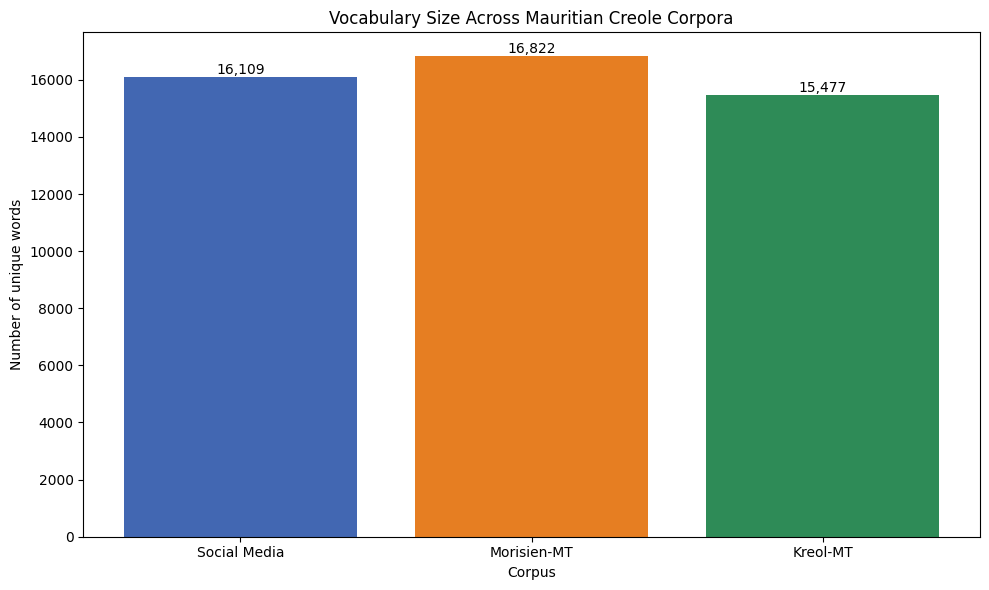


===== HAPAX LEGOMENA =====


,Corpus,Hapax count,Vocabulary size,Hapax percentage
0,Social Media,4156,16109,25.799243
1,Morisien-MT,10845,16822,64.469148
2,Kreol-MT,9905,15477,63.998191



Corpus: Social Media
Number of hapax words: 4156


,Word,Frequency
0,serviii,1
1,festivités,1
2,oubliettes,1
3,informus's,1
4,maha,1
5,batp,1
6,depression,1
7,partialiter,1
8,ztttt,1
9,battre,1



Corpus: Morisien-MT
Number of hapax words: 10845


...

,Combined MT vocabulary size,MT-only word count,MT-only percentage
0,17035,14543,85.371294



Most frequent MT-only words:


,word,frequency
0,ubyen,575
1,kriz,344
2,langaz,340
3,kimanyer,275
4,napoleon,269
5,diferan,267
6,boulkoton,220
7,guvernman,220
8,folklor,216
9,koson,192



===== JACCARD VOCABULARY SIMILARITY =====


,Social Media,Morisien-MT,Kreol-MT
Social Media,1.000000,0.080910,0.081564
Morisien-MT,0.080910,1.000000,0.896038
Kreol-MT,0.081564,0.896038,1.000000


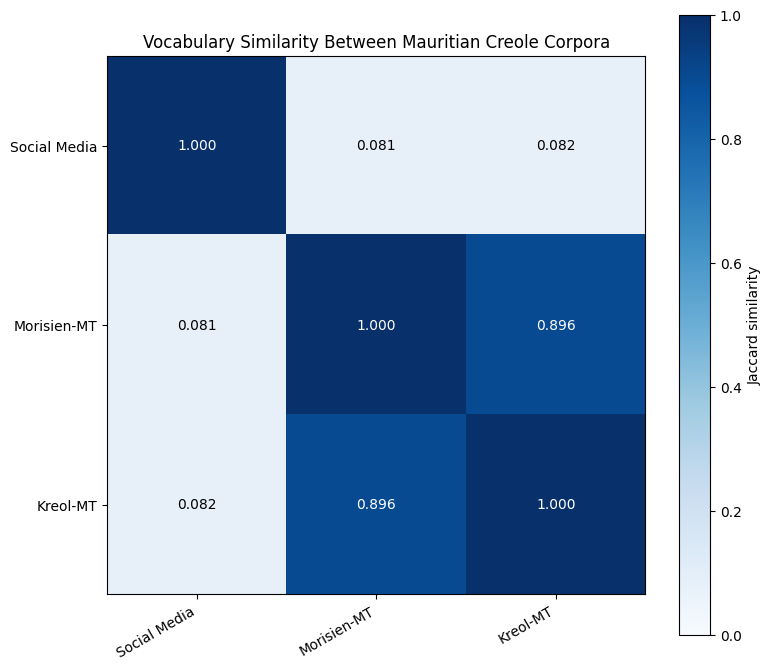


===== SOCIAL MEDIA VOCABULARY COVERAGE =====


,Resource comparison,Social vocabulary size,Covered social words,Missing social words,Vocabulary coverage percentage
0,Covered by Morisien-MT,16109,2465,13644,15.302005
1,Covered by Kreol-MT,16109,2382,13727,14.786765
2,Covered by either MT corpus,16109,2492,13617,15.469613



Results exported to: C:\Users\ae\OneDrive\thesis\lexical_analysis_results


In [95]:
import os
import re
import math
import unicodedata
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. TEXT NORMALIZATION AND TOKENIZATION
# ============================================================

def normalize_text(text):
    """
    Normalize text before lexical analysis.

    Operations:
    - Converts missing values to an empty string
    - Applies Unicode normalization
    - Converts text to lowercase using casefold()
    - Normalizes curly apostrophes
    - Removes URLs
    - Removes email addresses
    - Removes extra spaces

    Accented characters are preserved.
    """

    if pd.isna(text):
        return ""

    text = str(text)

    # Unicode normalization
    text = unicodedata.normalize("NFKC", text)

    # More complete than lower() for Unicode text
    text = text.casefold()

    # Normalize curly apostrophes
    text = text.replace("’", "'")
    text = text.replace("‘", "'")

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+\.\S+", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


def tokenize_text(text):
    """
    Extract lexical words from a sentence.

    This function does not hardcode punctuation marks.
    It reads characters using their Unicode categories.

    Letters are retained.
    Apostrophes and hyphens are retained only when they occur
    inside a word.

    Examples:
        "mo krwar twa" -> ["mo", "krwar", "twa"]
        "pa'le" -> ["pa'le"]
        "porte-monnaie" -> ["porte-monnaie"]

    Emojis, numbers and standalone punctuation are excluded
    from the lexical vocabulary analysis.
    """

    text = normalize_text(text)

    tokens = []
    current_word = []

    for index, character in enumerate(text):

        # Unicode categories beginning with L represent letters
        if unicodedata.category(character).startswith("L"):
            current_word.append(character)

        # Keep an apostrophe or hyphen only when it is between letters
        elif (
            character in {"'", "-"}
            and current_word
            and index + 1 < len(text)
            and unicodedata.category(text[index + 1]).startswith("L")
        ):
            current_word.append(character)

        else:
            if current_word:
                token = "".join(current_word).strip("'-")

                if token:
                    tokens.append(token)

                current_word = []

    # Add the final word
    if current_word:
        token = "".join(current_word).strip("'-")

        if token:
            tokens.append(token)

    return tokens


# ============================================================
# 2. PREPARE THE THREE CORPORA
# ============================================================

def prepare_corpus(dataframe, text_column, corpus_name):
    """
    Convert one DataFrame text column into a corpus dictionary.

    Returns:
        corpus name
        cleaned sentences
        tokenized sentences
        flattened token list
        frequency Counter
        vocabulary set
    """

    if text_column not in dataframe.columns:
        raise KeyError(
            f"Column '{text_column}' was not found in {corpus_name}.\n"
            f"Available columns: {list(dataframe.columns)}"
        )

    texts = (
        dataframe[text_column]
        .dropna()
        .astype(str)
        .tolist()
    )

    tokenized_sentences = [
        tokenize_text(text)
        for text in texts
    ]

    all_tokens = [
        token
        for sentence_tokens in tokenized_sentences
        for token in sentence_tokens
    ]

    frequency = Counter(all_tokens)
    vocabulary = set(frequency.keys())

    return {
        "name": corpus_name,
        "texts": texts,
        "tokenized_sentences": tokenized_sentences,
        "tokens": all_tokens,
        "frequency": frequency,
        "vocabulary": vocabulary
    }


def prepare_all_corpora(
    mc_joint_text_restoration_df,
    morisien_mt_df,
    kreol_mt_df
):
    """
    Prepare the three Mauritian Creole corpora.
    """

    corpora = {
        "Social Media": prepare_corpus(
            dataframe=mc_joint_text_restoration_df,
            text_column="text",
            corpus_name="Social Media"
        ),

        "Morisien-MT": prepare_corpus(
            dataframe=morisien_mt_df,
            text_column="target_text",
            corpus_name="Morisien-MT"
        ),

        "Kreol-MT": prepare_corpus(
            dataframe=kreol_mt_df,
            text_column="src_text",
            corpus_name="Kreol-MT"
        )
    }

    return corpora


# ============================================================
# 3. BASIC CORPUS INFORMATION
# ============================================================

def calculate_basic_corpus_statistics(corpora):
    """
    Calculate the number of records, tokens and empty records.
    """

    results = []

    for corpus_name, corpus in corpora.items():

        empty_records = sum(
            1
            for sentence_tokens in corpus["tokenized_sentences"]
            if len(sentence_tokens) == 0
        )

        results.append({
            "Corpus": corpus_name,
            "Number of records": len(corpus["texts"]),
            "Total tokens": len(corpus["tokens"]),
            "Empty lexical records": empty_records
        })

    return pd.DataFrame(results)


# ============================================================
# 4. VOCABULARY SIZE
# ============================================================

def calculate_vocabulary_size(corpora):
    """
    Vocabulary size is the number of distinct lexical types
    found in each corpus.
    """

    results = []

    for corpus_name, corpus in corpora.items():
        results.append({
            "Corpus": corpus_name,
            "Total tokens": len(corpus["tokens"]),
            "Vocabulary size": len(corpus["vocabulary"])
        })

    return pd.DataFrame(results)


def plot_vocabulary_size(vocabulary_size_df):
    """
    Visualize vocabulary size for the three corpora.
    """

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        vocabulary_size_df["Corpus"],
        vocabulary_size_df["Vocabulary size"],
        color=["#4267B2", "#E67E22", "#2E8B57"]
    )

    plt.title("Vocabulary Size Across Mauritian Creole Corpora")
    plt.xlabel("Corpus")
    plt.ylabel("Number of unique words")

    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height):,}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 5. HAPAX LEGOMENA
# ============================================================

def calculate_hapax_legomena(corpora):
    """
    Hapax legomena are words occurring exactly once in a corpus.

    Returns:
        summary DataFrame
        detailed dictionary of hapax words
    """

    summary_results = []
    detailed_results = {}

    for corpus_name, corpus in corpora.items():

        hapax_words = {
            word: frequency
            for word, frequency in corpus["frequency"].items()
            if frequency == 1
        }

        vocabulary_size = len(corpus["vocabulary"])

        hapax_percentage = (
            len(hapax_words) / vocabulary_size * 100
            if vocabulary_size > 0
            else 0
        )

        detailed_results[corpus_name] = hapax_words

        summary_results.append({
            "Corpus": corpus_name,
            "Hapax count": len(hapax_words),
            "Vocabulary size": vocabulary_size,
            "Hapax percentage": hapax_percentage
        })

    return pd.DataFrame(summary_results), detailed_results


def plot_hapax_legomena(hapax_summary_df):
    """
    Visualize hapax legomena counts.
    """

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        hapax_summary_df["Corpus"],
        hapax_summary_df["Hapax count"],
        color=["#4267B2", "#E67E22", "#2E8B57"]
    )

    plt.title("Hapax Legomena Across the Three Corpora")
    plt.xlabel("Corpus")
    plt.ylabel("Number of words occurring once")

    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height):,}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 6. RARE WORDS
# ============================================================

def calculate_rare_words(corpora, maximum_frequency=5):
    """
    Identify words occurring between 1 and maximum_frequency times.

    The threshold is configurable.

    For example:
        maximum_frequency=5

    means that words occurring 1, 2, 3, 4 or 5 times
    are classified as rare.
    """

    summary_results = []
    detailed_results = {}

    for corpus_name, corpus in corpora.items():

        rare_words = {
            word: frequency
            for word, frequency in corpus["frequency"].items()
            if 1 <= frequency <= maximum_frequency
        }

        rare_words = dict(
            sorted(
                rare_words.items(),
                key=lambda item: (item[1], item[0])
            )
        )

        vocabulary_size = len(corpus["vocabulary"])

        rare_percentage = (
            len(rare_words) / vocabulary_size * 100
            if vocabulary_size > 0
            else 0
        )

        detailed_results[corpus_name] = rare_words

        summary_results.append({
            "Corpus": corpus_name,
            "Rare-word threshold": maximum_frequency,
            "Rare-word count": len(rare_words),
            "Vocabulary size": vocabulary_size,
            "Rare-word percentage": rare_percentage
        })

    return pd.DataFrame(summary_results), detailed_results


def plot_rare_words(rare_words_summary_df):
    """
    Visualize the number of rare vocabulary items.
    """

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        rare_words_summary_df["Corpus"],
        rare_words_summary_df["Rare-word count"],
        color=["#4267B2", "#E67E22", "#2E8B57"]
    )

    threshold = rare_words_summary_df[
        "Rare-word threshold"
    ].iloc[0]

    plt.title(
        f"Rare Words Across the Corpora "
        f"(Frequency ≤ {threshold})"
    )

    plt.xlabel("Corpus")
    plt.ylabel("Number of rare vocabulary items")

    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height):,}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 7. TYPE-TOKEN RATIO
# ============================================================

def calculate_type_token_ratio(corpora):
    """
    Type-Token Ratio:

        TTR = number of unique words / total number of words

    TTR is affected by corpus size, so results must be
    interpreted carefully when corpora have different sizes.
    """

    results = []

    for corpus_name, corpus in corpora.items():

        token_count = len(corpus["tokens"])
        type_count = len(corpus["vocabulary"])

        type_token_ratio = (
            type_count / token_count
            if token_count > 0
            else 0
        )

        results.append({
            "Corpus": corpus_name,
            "Types": type_count,
            "Tokens": token_count,
            "Type-token ratio": type_token_ratio,
            "Type-token percentage": type_token_ratio * 100
        })

    return pd.DataFrame(results)


def plot_type_token_ratio(ttr_df):
    """
    Visualize Type-Token Ratio as a percentage.
    """

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        ttr_df["Corpus"],
        ttr_df["Type-token percentage"],
        color=["#4267B2", "#E67E22", "#2E8B57"]
    )

    plt.title("Type-Token Ratio Across Mauritian Creole Corpora")
    plt.xlabel("Corpus")
    plt.ylabel("Type-Token Ratio (%)")

    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.2f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 8. MOVING-AVERAGE TYPE-TOKEN RATIO
# ============================================================

def calculate_mattr_for_tokens(tokens, window_size=500):
    """
    Calculate Moving-Average Type-Token Ratio (MATTR).

    MATTR reduces the influence of different corpus sizes.

    If the corpus contains fewer tokens than the selected
    window, the ordinary TTR is returned.
    """

    if not tokens:
        return 0

    if len(tokens) <= window_size:
        return len(set(tokens)) / len(tokens)

    window_ttr_values = []

    for start_position in range(
        0,
        len(tokens) - window_size + 1
    ):
        token_window = tokens[
            start_position:start_position + window_size
        ]

        window_ttr = (
            len(set(token_window)) / window_size
        )

        window_ttr_values.append(window_ttr)

    return (
        sum(window_ttr_values) /
        len(window_ttr_values)
    )


def calculate_mattr(corpora, window_size=500):
    """
    Calculate MATTR for all corpora.
    """

    results = []

    for corpus_name, corpus in corpora.items():

        mattr_score = calculate_mattr_for_tokens(
            corpus["tokens"],
            window_size=window_size
        )

        results.append({
            "Corpus": corpus_name,
            "Window size": window_size,
            "MATTR": mattr_score,
            "MATTR percentage": mattr_score * 100
        })

    return pd.DataFrame(results)


def plot_mattr(mattr_df):
    """
    Visualize Moving-Average Type-Token Ratio.
    """

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        mattr_df["Corpus"],
        mattr_df["MATTR percentage"],
        color=["#4267B2", "#E67E22", "#2E8B57"]
    )

    window_size = mattr_df["Window size"].iloc[0]

    plt.title(
        f"Moving-Average Type-Token Ratio "
        f"(Window = {window_size} tokens)"
    )

    plt.xlabel("Corpus")
    plt.ylabel("MATTR (%)")

    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.2f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 9. SHARED VOCABULARY
# ============================================================

def calculate_shared_vocabulary(corpora):
    """
    Calculate vocabulary shared between corpus pairs and
    vocabulary shared by all three corpora.
    """

    social_vocabulary = corpora[
        "Social Media"
    ]["vocabulary"]

    morisien_vocabulary = corpora[
        "Morisien-MT"
    ]["vocabulary"]

    kreol_vocabulary = corpora[
        "Kreol-MT"
    ]["vocabulary"]

    shared_social_morisien = (
        social_vocabulary &
        morisien_vocabulary
    )

    shared_social_kreol = (
        social_vocabulary &
        kreol_vocabulary
    )

    shared_morisien_kreol = (
        morisien_vocabulary &
        kreol_vocabulary
    )

    shared_all_three = (
        social_vocabulary &
        morisien_vocabulary &
        kreol_vocabulary
    )

    summary_df = pd.DataFrame([
        {
            "Comparison": "Social Media and Morisien-MT",
            "Shared vocabulary size":
                len(shared_social_morisien)
        },
        {
            "Comparison": "Social Media and Kreol-MT",
            "Shared vocabulary size":
                len(shared_social_kreol)
        },
        {
            "Comparison": "Morisien-MT and Kreol-MT",
            "Shared vocabulary size":
                len(shared_morisien_kreol)
        },
        {
            "Comparison": "All three corpora",
            "Shared vocabulary size":
                len(shared_all_three)
        }
    ])

    detailed_results = {
        "social_morisien": shared_social_morisien,
        "social_kreol": shared_social_kreol,
        "morisien_kreol": shared_morisien_kreol,
        "all_three": shared_all_three
    }

    return summary_df, detailed_results


def plot_shared_vocabulary(shared_vocabulary_df):
    """
    Visualize shared vocabulary sizes.
    """

    plt.figure(figsize=(11, 6))

    bars = plt.barh(
        shared_vocabulary_df["Comparison"],
        shared_vocabulary_df["Shared vocabulary size"],
        color="#6C5CE7"
    )

    plt.title("Shared Vocabulary Between Mauritian Creole Corpora")
    plt.xlabel("Number of shared words")
    plt.ylabel("Corpus comparison")

    for bar in bars:
        width = bar.get_width()

        plt.text(
            width,
            bar.get_y() + bar.get_height() / 2,
            f" {int(width):,}",
            va="center"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 10. SOCIAL-MEDIA-ONLY WORDS / OOV WORDS
# ============================================================

def calculate_social_media_only_words(corpora):
    """
    Identify words found in the social media corpus but absent
    from both MT corpora.

    These words are OOV relative to the combined MT vocabulary.
    """

    social_frequency = corpora[
        "Social Media"
    ]["frequency"]

    social_vocabulary = corpora[
        "Social Media"
    ]["vocabulary"]

    combined_mt_vocabulary = (
        corpora["Morisien-MT"]["vocabulary"] |
        corpora["Kreol-MT"]["vocabulary"]
    )

    social_only_vocabulary = (
        social_vocabulary -
        combined_mt_vocabulary
    )

    social_only_frequency = {
        word: social_frequency[word]
        for word in social_only_vocabulary
    }

    social_only_frequency = dict(
        sorted(
            social_only_frequency.items(),
            key=lambda item: (-item[1], item[0])
        )
    )

    social_vocabulary_size = len(social_vocabulary)

    oov_rate = (
        len(social_only_vocabulary) /
        social_vocabulary_size
        if social_vocabulary_size > 0
        else 0
    )

    summary = {
        "Social media vocabulary size":
            social_vocabulary_size,

        "Social-media-only word count":
            len(social_only_vocabulary),

        "Social-media OOV rate":
            oov_rate,

        "Social-media OOV percentage":
            oov_rate * 100
    }

    return summary, social_only_frequency


def plot_social_media_only_words(
    social_only_words,
    top_n=30
):
    """
    Visualize the most frequent social-media-only words.
    """

    top_words = list(
        social_only_words.items()
    )[:top_n]

    if not top_words:
        print("No social-media-only words were found.")
        return

    words = [
        item[0]
        for item in top_words
    ]

    frequencies = [
        item[1]
        for item in top_words
    ]

    words = words[::-1]
    frequencies = frequencies[::-1]

    plt.figure(figsize=(11, 9))

    bars = plt.barh(
        words,
        frequencies,
        color="#4267B2"
    )

    plt.title(
        f"Top {len(words)} Social-Media-Only Words"
    )

    plt.xlabel("Frequency in the social media corpus")
    plt.ylabel("Word")

    for bar in bars:
        width = bar.get_width()

        plt.text(
            width,
            bar.get_y() + bar.get_height() / 2,
            f" {int(width):,}",
            va="center"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 11. MT-ONLY WORDS
# ============================================================

def calculate_mt_only_words(corpora):
    """
    Identify words found in at least one MT corpus but absent
    from the social media corpus.
    """

    social_vocabulary = corpora[
        "Social Media"
    ]["vocabulary"]

    morisien_frequency = corpora[
        "Morisien-MT"
    ]["frequency"]

    kreol_frequency = corpora[
        "Kreol-MT"
    ]["frequency"]

    combined_mt_vocabulary = (
        corpora["Morisien-MT"]["vocabulary"] |
        corpora["Kreol-MT"]["vocabulary"]
    )

    mt_only_vocabulary = (
        combined_mt_vocabulary -
        social_vocabulary
    )

    mt_only_frequency = {}

    for word in mt_only_vocabulary:
        mt_only_frequency[word] = (
            morisien_frequency.get(word, 0) +
            kreol_frequency.get(word, 0)
        )

    mt_only_frequency = dict(
        sorted(
            mt_only_frequency.items(),
            key=lambda item: (-item[1], item[0])
        )
    )

    summary = {
        "Combined MT vocabulary size":
            len(combined_mt_vocabulary),

        "MT-only word count":
            len(mt_only_vocabulary),

        "MT-only percentage":
            (
                len(mt_only_vocabulary) /
                len(combined_mt_vocabulary) * 100
                if combined_mt_vocabulary
                else 0
            )
    }

    return summary, mt_only_frequency


def plot_mt_only_words(mt_only_words, top_n=30):
    """
    Visualize the most frequent MT-only words.
    """

    top_words = list(
        mt_only_words.items()
    )[:top_n]

    if not top_words:
        print("No MT-only words were found.")
        return

    words = [
        item[0]
        for item in top_words
    ][::-1]

    frequencies = [
        item[1]
        for item in top_words
    ][::-1]

    plt.figure(figsize=(11, 9))

    bars = plt.barh(
        words,
        frequencies,
        color="#E67E22"
    )

    plt.title(
        f"Top {len(words)} MT-Only Words"
    )

    plt.xlabel("Combined frequency in the MT corpora")
    plt.ylabel("Word")

    for bar in bars:
        width = bar.get_width()

        plt.text(
            width,
            bar.get_y() + bar.get_height() / 2,
            f" {int(width):,}",
            va="center"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 12. JACCARD VOCABULARY SIMILARITY
# ============================================================

def calculate_jaccard_similarity(
    first_vocabulary,
    second_vocabulary
):
    """
    Calculate Jaccard similarity.

    Jaccard similarity =
        intersection size / union size
    """

    union = (
        first_vocabulary |
        second_vocabulary
    )

    intersection = (
        first_vocabulary &
        second_vocabulary
    )

    if not union:
        return 0

    return len(intersection) / len(union)


def calculate_jaccard_similarity_matrix(corpora):
    """
    Create a pairwise Jaccard similarity matrix.
    """

    corpus_names = list(corpora.keys())

    similarity_matrix = pd.DataFrame(
        index=corpus_names,
        columns=corpus_names,
        dtype=float
    )

    for first_corpus in corpus_names:
        for second_corpus in corpus_names:

            first_vocabulary = corpora[
                first_corpus
            ]["vocabulary"]

            second_vocabulary = corpora[
                second_corpus
            ]["vocabulary"]

            similarity_matrix.loc[
                first_corpus,
                second_corpus
            ] = calculate_jaccard_similarity(
                first_vocabulary,
                second_vocabulary
            )

    return similarity_matrix


def plot_jaccard_similarity_matrix(similarity_matrix):
    """
    Visualize pairwise lexical similarity as a heatmap.
    """

    plt.figure(figsize=(8, 7))

    image = plt.imshow(
        similarity_matrix.values,
        cmap="Blues",
        vmin=0,
        vmax=1
    )

    plt.colorbar(
        image,
        label="Jaccard similarity"
    )

    corpus_names = similarity_matrix.columns.tolist()

    plt.xticks(
        range(len(corpus_names)),
        corpus_names,
        rotation=30,
        ha="right"
    )

    plt.yticks(
        range(len(corpus_names)),
        corpus_names
    )

    for row_index in range(
        len(similarity_matrix.index)
    ):
        for column_index in range(
            len(similarity_matrix.columns)
        ):
            score = similarity_matrix.iloc[
                row_index,
                column_index
            ]

            text_color = (
                "white"
                if score > 0.50
                else "black"
            )

            plt.text(
                column_index,
                row_index,
                f"{score:.3f}",
                ha="center",
                va="center",
                color=text_color
            )

    plt.title(
        "Vocabulary Similarity Between Mauritian Creole Corpora"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 13. VOCABULARY COVERAGE
# ============================================================

def calculate_social_media_vocabulary_coverage(corpora):
    """
    Calculate how much of the social media vocabulary is
    covered by each resource and by both MT resources combined.

    This directly supports the research question.
    """

    social_vocabulary = corpora[
        "Social Media"
    ]["vocabulary"]

    morisien_vocabulary = corpora[
        "Morisien-MT"
    ]["vocabulary"]

    kreol_vocabulary = corpora[
        "Kreol-MT"
    ]["vocabulary"]

    combined_mt_vocabulary = (
        morisien_vocabulary |
        kreol_vocabulary
    )

    comparisons = {
        "Covered by Morisien-MT":
            morisien_vocabulary,

        "Covered by Kreol-MT":
            kreol_vocabulary,

        "Covered by either MT corpus":
            combined_mt_vocabulary
    }

    results = []

    for resource_name, resource_vocabulary in comparisons.items():

        covered_words = (
            social_vocabulary &
            resource_vocabulary
        )

        missing_words = (
            social_vocabulary -
            resource_vocabulary
        )

        coverage_rate = (
            len(covered_words) /
            len(social_vocabulary)
            if social_vocabulary
            else 0
        )

        results.append({
            "Resource comparison": resource_name,
            "Social vocabulary size":
                len(social_vocabulary),
            "Covered social words":
                len(covered_words),
            "Missing social words":
                len(missing_words),
            "Vocabulary coverage percentage":
                coverage_rate * 100
        })

    return pd.DataFrame(results)


def plot_vocabulary_coverage(coverage_df):
    """
    Visualize social media vocabulary coverage.
    """

    plt.figure(figsize=(11, 6))

    bars = plt.bar(
        coverage_df["Resource comparison"],
        coverage_df["Vocabulary coverage percentage"],
        color=["#E67E22", "#2E8B57", "#6C5CE7"]
    )

    plt.title(
        "Coverage of Social Media Vocabulary by Existing MC Resources"
    )

    plt.xlabel("Resource")
    plt.ylabel("Social media vocabulary covered (%)")
    plt.ylim(0, 100)

    plt.xticks(
        rotation=20,
        ha="right"
    )

    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.2f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 14. EXPORT RESULTS
# ============================================================

def dictionary_to_dataframe(
    word_frequency_dictionary
):
    """
    Convert a word-frequency dictionary into a DataFrame.
    """

    return pd.DataFrame(
        [
            {
                "word": word,
                "frequency": frequency
            }
            for word, frequency
            in word_frequency_dictionary.items()
        ]
    )


def set_to_dataframe(word_set):
    """
    Convert a vocabulary set into a sorted DataFrame.
    """

    return pd.DataFrame({
        "word": sorted(word_set)
    })


def export_lexical_results(
    output_directory,
    basic_statistics_df,
    vocabulary_size_df,
    hapax_summary_df,
    hapax_details,
    rare_summary_df,
    rare_details,
    ttr_df,
    mattr_df,
    shared_summary_df,
    shared_details,
    social_only_summary,
    social_only_words,
    mt_only_summary,
    mt_only_words,
    jaccard_matrix,
    coverage_df
):
    """
    Export all lexical results to CSV files.
    """

    os.makedirs(
        output_directory,
        exist_ok=True
    )

    basic_statistics_df.to_csv(
        os.path.join(
            output_directory,
            "basic_corpus_statistics.csv"
        ),
        index=False,
        encoding="utf-8-sig"
    )

    vocabulary_size_df.to_csv(
        os.path.join(
            output_directory,
            "vocabulary_size.csv"
        ),
        index=False,
        encoding="utf-8-sig"
    )

    hapax_summary_df.to_csv(
        os.path.join(
            output_directory,
            "hapax_summary.csv"
        ),
        index=False,
        encoding="utf-8-sig"
    )

    for corpus_name, words in hapax_details.items():

        safe_name = (
            corpus_name
            .lower()
            .replace(" ", "_")
            .replace("-", "_")
        )

        dictionary_to_dataframe(words).to_csv(
            os.path.join(
                output_directory,
                f"hapax_{safe_name}.csv"
            ),
            index=False,
            encoding="utf-8-sig"
        )

    rare_summary_df.to_csv(
        os.path.join(
            output_directory,
            "rare_words_summary.csv"
        ),
        index=False,
        encoding="utf-8-sig"
    )

    for corpus_name, words in rare_details.items():

        safe_name = (
            corpus_name
            .lower()
            .replace(" ", "_")
            .replace("-", "_")
        )

        dictionary_to_dataframe(words).to_csv(
            os.path.join(
                output_directory,
                f"rare_words_{safe_name}.csv"
            ),
            index=False,
            encoding="utf-8-sig"
        )

    ttr_df.to_csv(
        os.path.join(
            output_directory,
            "type_token_ratio.csv"
        ),
        index=False,
        encoding="utf-8-sig"
    )

    mattr_df.to_csv(
        os.path.join(
            output_directory,
            "mattr.csv"
        ),
        index=False,
        encoding="utf-8-sig"
    )

    shared_summary_df.to_csv(
        os.path.join(
            output_directory,
            "shared_vocabulary_summary.csv"
        ),
        index=False,
        encoding="utf-8-sig"
    )

    for comparison_name, words in shared_details.items():

        set_to_dataframe(words).to_csv(
            os.path.join(
                output_directory,
                f"shared_{comparison_name}.csv"
            ),
            index=False,
            encoding="utf-8-sig"
        )

    pd.DataFrame([
        social_only_summary
    ]).to_csv(
        os.path.join(
            output_directory,
            "social_media_oov_summary.csv"
        ),
        index=False,
        encoding="utf-8-sig"
    )

    dictionary_to_dataframe(
        social_only_words
    ).to_csv(
        os.path.join(
            output_directory,
            "social_media_only_words.csv"
        ),
        index=False,
        encoding="utf-8-sig"
    )

    pd.DataFrame([
        mt_only_summary
    ]).to_csv(
        os.path.join(
            output_directory,
            "mt_only_summary.csv"
        ),
        index=False,
        encoding="utf-8-sig"
    )

    dictionary_to_dataframe(
        mt_only_words
    ).to_csv(
        os.path.join(
            output_directory,
            "mt_only_words.csv"
        ),
        index=False,
        encoding="utf-8-sig"
    )

    jaccard_matrix.to_csv(
        os.path.join(
            output_directory,
            "jaccard_similarity_matrix.csv"
        ),
        encoding="utf-8-sig"
    )

    coverage_df.to_csv(
        os.path.join(
            output_directory,
            "social_media_vocabulary_coverage.csv"
        ),
        index=False,
        encoding="utf-8-sig"
    )

    print(
        "\nResults exported to:",
        output_directory
    )


# ============================================================
# 15. MAIN FUNCTION
# ============================================================

def main():
    """
    Run the complete lexical comparison.
    """

    # You can change this folder if necessary
    output_directory = (
        r"C:\Users\ae\OneDrive\thesis"
        r"\lexical_analysis_results"
    )

    rare_word_threshold = 5
    mattr_window_size = 500
    number_of_words_to_plot = 30

    # --------------------------------------------------------
    # Prepare corpora
    # --------------------------------------------------------

    corpora = prepare_all_corpora(
        mc_joint_text_restoration_df,
        morisien_mt_df,
        kreol_mt_df
    )

    # --------------------------------------------------------
    # Basic statistics
    # --------------------------------------------------------

    basic_statistics_df = (
        calculate_basic_corpus_statistics(corpora)
    )

    print("\n===== BASIC CORPUS STATISTICS =====")
    display(basic_statistics_df)

    # --------------------------------------------------------
    # Vocabulary size
    # --------------------------------------------------------

    vocabulary_size_df = (
        calculate_vocabulary_size(corpora)
    )

    print("\n===== VOCABULARY SIZE =====")
    display(vocabulary_size_df)

    plot_vocabulary_size(
        vocabulary_size_df
    )

    # --------------------------------------------------------
    # Hapax legomena
    # --------------------------------------------------------

    (
        hapax_summary_df,
        hapax_details
    ) = calculate_hapax_legomena(corpora)

    print("\n===== HAPAX LEGOMENA =====")
    display(hapax_summary_df)

    # --------------------------------------------------------
    # Display hapax words
    # --------------------------------------------------------

    for corpus_name, hapax_words in hapax_details.items():

        print("\n====================================")
        print("Corpus:", corpus_name)
        print("Number of hapax words:", len(hapax_words))
        print("====================================")

        hapax_df = pd.DataFrame(
            {
                "Word": list(hapax_words.keys()),
                "Frequency": list(hapax_words.values())
            }
        )

        display(
            hapax_df.head(50)
        )

    # plot_hapax_legomena(
    #     hapax_summary_df
    # )

    # --------------------------------------------------------
    # Rare words
    # --------------------------------------------------------

    (
        rare_summary_df,
        rare_details
    ) = calculate_rare_words(
        corpora,
        maximum_frequency=rare_word_threshold
    )

    print("\n===== RARE WORDS =====")
    display(rare_summary_df)

    # plot_rare_words(
    #     rare_summary_df
    # )

    # --------------------------------------------------------
    # Type-token ratio
    # --------------------------------------------------------

    ttr_df = calculate_type_token_ratio(
        corpora
    )

    print("\n===== TYPE-TOKEN RATIO =====")
    display(ttr_df)

    # plot_type_token_ratio(
    #     ttr_df
    # )

    # --------------------------------------------------------
    # MATTR
    # --------------------------------------------------------

    mattr_df = calculate_mattr(
        corpora,
        window_size=mattr_window_size
    )

    print("\n===== MOVING-AVERAGE TYPE-TOKEN RATIO =====")
    display(mattr_df)

    # plot_mattr(
    #     mattr_df
    # )

    # --------------------------------------------------------
    # Shared vocabulary
    # --------------------------------------------------------

    (
        shared_summary_df,
        shared_details
    ) = calculate_shared_vocabulary(corpora)

    print("\n===== SHARED VOCABULARY =====")
    display(shared_summary_df)

    # plot_shared_vocabulary(
    #     shared_summary_df
    # )

    # --------------------------------------------------------
    # Shared vocabulary frequency table
    # --------------------------------------------------------

    shared_all_three_words = shared_details["all_three"]

    shared_frequency_rows = []


    for word in shared_all_three_words:

        shared_frequency_rows.append({

            "Word": word,

            "Social Media frequency":
                corpora["Social Media"]["frequency"].get(word, 0),

            "Morisien-MT frequency":
                corpora["Morisien-MT"]["frequency"].get(word, 0),

            "Kreol-MT frequency":
                corpora["Kreol-MT"]["frequency"].get(word, 0)

        })


    shared_frequency_df = pd.DataFrame(
        shared_frequency_rows
    )


    shared_frequency_df = (
        shared_frequency_df
        .sort_values(
            by="Social Media frequency",
            ascending=False
        )
    )


    print("\n===== MOST FREQUENT WORDS SHARED BY ALL THREE =====")

    display(
        shared_frequency_df.head(20)
    )
    # --------------------------------------------------------
    # Social-media-only/OOV words
    # --------------------------------------------------------

    (
        social_only_summary,
        social_only_words
    ) = calculate_social_media_only_words(corpora)

    print("\n===== SOCIAL-MEDIA-ONLY / OOV WORDS =====")

    display(
        pd.DataFrame([
            social_only_summary
        ])
    )

    print("\nMost frequent social-media-only words:")

    display(
        dictionary_to_dataframe(
            social_only_words
        ).head(30)
    )

    # plot_social_media_only_words(
    #     social_only_words,
    #     top_n=number_of_words_to_plot
    # )

    # --------------------------------------------------------
    # MT-only words
    # --------------------------------------------------------

    (
        mt_only_summary,
        mt_only_words
    ) = calculate_mt_only_words(corpora)

    print("\n===== MT-ONLY WORDS =====")

    display(
        pd.DataFrame([
            mt_only_summary
        ])
    )

    print("\nMost frequent MT-only words:")

    display(
        dictionary_to_dataframe(
            mt_only_words
        ).head(30)
    )

    # plot_mt_only_words(
    #     mt_only_words,
    #     top_n=number_of_words_to_plot
    # )

    # --------------------------------------------------------
    # Jaccard vocabulary similarity
    # --------------------------------------------------------

    jaccard_matrix = (
        calculate_jaccard_similarity_matrix(corpora)
    )

    print("\n===== JACCARD VOCABULARY SIMILARITY =====")
    display(jaccard_matrix)

    plot_jaccard_similarity_matrix(
        jaccard_matrix
    )

    # --------------------------------------------------------
    # Social media vocabulary coverage
    # --------------------------------------------------------

    coverage_df = (
        calculate_social_media_vocabulary_coverage(
            corpora
        )
    )

    print("\n===== SOCIAL MEDIA VOCABULARY COVERAGE =====")
    display(coverage_df)

    # plot_vocabulary_coverage(
    #     coverage_df
    # )

    # --------------------------------------------------------
    # Export results
    # --------------------------------------------------------

    export_lexical_results(
        output_directory=output_directory,
        basic_statistics_df=basic_statistics_df,
        vocabulary_size_df=vocabulary_size_df,
        hapax_summary_df=hapax_summary_df,
        hapax_details=hapax_details,
        rare_summary_df=rare_summary_df,
        rare_details=rare_details,
        ttr_df=ttr_df,
        mattr_df=mattr_df,
        shared_summary_df=shared_summary_df,
        shared_details=shared_details,
        social_only_summary=social_only_summary,
        social_only_words=social_only_words,
        mt_only_summary=mt_only_summary,
        mt_only_words=mt_only_words,
        jaccard_matrix=jaccard_matrix,
        coverage_df=coverage_df
    )


# Run the analysis
main()

In [87]:
# Find Facebook records that become empty after tokenization

empty_records = []

for index, text in enumerate(mc_joint_text_restoration_df["text"]):

    tokens = tokenize_text(text)

    if len(tokens) == 0:
        empty_records.append({
            "index": index,
            "id": mc_joint_text_restoration_df.iloc[index]["id"],
            "original_text": text,
            "standardized": mc_joint_text_restoration_df.iloc[index]["standardized"]
        })


empty_records_df = pd.DataFrame(empty_records)

display(empty_records_df)

,index,id,original_text,standardized
0,5024,5025,🇲🇺 = 🤡,🇲🇺 = 🤡.


#### ◆ Orthographic variations analysis

##### ◆◆ Orthographic variation - [1] Diacritical analysis

In [2]:
def tokenize_for_diacritics(text):
    """
    Extract words while preserving accented characters.
    """

    if pd.isna(text):
        return []

    text = str(text).lower()

    # Keep letters including accented Unicode characters
    words = re.findall(
        r"[a-zàâçéèêëîïôûùü]+",
        text
    )

    return words


def get_diacritical_words(
    dataframe,
    text_column
):
    """
    Find words containing diacritical marks.

    Returns:
        word frequencies
    """

    counter = Counter()

    for text in dataframe[text_column]:

        words = tokenize_for_diacritics(text)

        for word in words:

            if (
                len(word) > 1
                and
                re.search(
                    r"[àâçéèêëîïôûùü]",
                    word
                )
            ):
                counter[word] += 1

    return counter


def diacritical_summary(
    dataframe,
    text_column,
    corpus_name
):
    """
    Create summary statistics.
    """

    diacritical_words = get_diacritical_words(
        dataframe,
        text_column
    )

    total_words = sum(diacritical_words.values())

    return pd.DataFrame([
        {
            "Corpus": corpus_name,
            "Number of diacritical word types":
                len(diacritical_words),

            "Number of diacritical word occurrences":
                total_words,

            "Most frequent examples":
                ", ".join(
                    [
                        f"{word} ({count})"
                        for word, count
                        in diacritical_words.most_common(10)
                    ]
                )
        }
    ])

In [3]:
def diacritical_word_table(
    dataframe,
    text_column,
    corpus_name,
    top_n=30
):
    """
    Return the most frequent words containing diacritics.
    """

    words = get_diacritical_words(
        dataframe,
        text_column
    )

    results = []

    for word, frequency in words.most_common(top_n):

        results.append({
            "Corpus": corpus_name,
            "Word": word,
            "Frequency": frequency
        })

    return pd.DataFrame(results)

def diacritical_summary_with_counts(
    dataframe,
    text_column,
    corpus_name
):

    words = get_diacritical_words(
        dataframe,
        text_column
    )

    return pd.DataFrame([
        {
            "Corpus": corpus_name,
            "Diacritical word types": len(words),
            "Diacritical word occurrences": sum(words.values())
        }
    ])

In [11]:
facebook_diacritical_words = diacritical_word_table(
    mc_joint_text_restoration_df,
    "text",
    "Facebook corpus",
    top_n=1402
)

morisien_diacritical_words = diacritical_word_table(
    morisien_mt_df,
    "target_text",
    "Morisien-MT",
    top_n=30
)

kreol_diacritical_words = diacritical_word_table(
    kreol_mt_df,
    "src_text",
    "Kreol-MT",
    top_n=30
)

display(facebook_diacritical_words)
display(morisien_diacritical_words)
display(kreol_diacritical_words)

diacritical_summary = pd.concat(
    [
        diacritical_summary_with_counts(
            mc_joint_text_restoration_df,
            "text",
            "Facebook corpus"
        ),

        diacritical_summary_with_counts(
            morisien_mt_df,
            "target_text",
            "Morisien-MT"
        ),

        diacritical_summary_with_counts(
            kreol_mt_df,
            "src_text",
            "Kreol-MT"
        )
    ],
    ignore_index=True
)

display(diacritical_summary)

facebook_diacritical_words.to_csv(
    "facebook_diacritical_words.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Facebook diacritical words saved.")

,Corpus,Word,Frequency
0,Facebook corpus,même,152
1,Facebook corpus,ça,120
2,Facebook corpus,après,114
3,Facebook corpus,là,86
4,Facebook corpus,pé,58
...,...,...,...
1394,Facebook corpus,trimé,1
1395,Facebook corpus,dépasse,1
1396,Facebook corpus,loué,1
1397,Facebook corpus,prémié,1


,Corpus,Word,Frequency
0,Morisien-MT,santé,7
1,Morisien-MT,prêt,2
2,Morisien-MT,mée,2
3,Morisien-MT,émigré,1
4,Morisien-MT,passé,1
5,Morisien-MT,arête,1
6,Morisien-MT,josé,1
7,Morisien-MT,bové,1
8,Morisien-MT,bérenger,1
9,Morisien-MT,chaussée,1


,Corpus,Word,Frequency
0,Kreol-MT,santé,6
1,Kreol-MT,én,2
2,Kreol-MT,mée,2
3,Kreol-MT,invité,1
4,Kreol-MT,lanivérser,1
5,Kreol-MT,émigré,1
6,Kreol-MT,léléktora,1
7,Kreol-MT,fér,1
8,Kreol-MT,passé,1
9,Kreol-MT,géj,1


,Corpus,Diacritical word types,Diacritical word occurrences
0,Facebook corpus,1399,5743
1,Morisien-MT,12,20
2,Kreol-MT,17,24


Facebook diacritical words saved.


##### ◆◆ Orthographic variation - [2] Character repetition

In [64]:
def normalize_text(text):
    """
    Basic text cleaning while preserving repeated letters.
    """

    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Keep letters, apostrophes and spaces
    text = re.sub(r"[^a-zàâçéèêëîïôûùü\s']", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


def tokenize(text):
    """
    Split cleaned text into words.
    """

    return normalize_text(text).split()

# ============================================================
# WORD FREQUENCIES
# ============================================================

def get_word_frequency(
    dataframe,
    text_column
):
    """
    Count the frequency of every word in a corpus.
    """

    counter = Counter()

    for text in dataframe[text_column]:
        counter.update(tokenize(text))

    return counter

# ============================================================
# DETECT CHARACTER REPETITION
# ============================================================

def has_repeated_letters(word):
    """
    Detect words containing a character repeated
    three or more consecutive times.

    Examples:
        laaa
        merciii
        pffff
        etaaaa
    """

    return bool(
        re.search(
            r"(.)\1{2,}",
            word
        )
    )


def get_repeated_letter_words(
    dataframe,
    text_column
):
    """
    Return all repeated-letter words with their frequencies.
    """

    frequency = get_word_frequency(
        dataframe,
        text_column
    )

    repeated = Counter()

    for word, count in frequency.items():

        if has_repeated_letters(word):

            repeated[word] = count

    return repeated

# ============================================================
# SUMMARY TABLE
# ============================================================

def repeated_letter_summary(
    dataframe,
    text_column,
    corpus_name
):
    """
    Produce summary statistics for repeated-letter words.
    """

    frequency = get_word_frequency(
        dataframe,
        text_column
    )

    repeated = get_repeated_letter_words(
        dataframe,
        text_column
    )

    total_word_types = len(frequency)
    total_word_occurrences = sum(frequency.values())

    repeated_types = len(repeated)
    repeated_occurrences = sum(repeated.values())

    percentage = (
        repeated_occurrences /
        total_word_occurrences * 100
    ) if total_word_occurrences else 0

    return pd.DataFrame([{

        "Corpus": corpus_name,

        "Repeated word types":
            repeated_types,

        "Repeated word occurrences":
            repeated_occurrences,

        "Percentage of all word occurrences":
            round(
                percentage,
                3
            )

    }])


# ============================================================
# MOST FREQUENT REPEATED WORDS
# ============================================================

def repeated_letter_table(
    dataframe,
    text_column,
    corpus_name,
    top_n=20
):
    """
    Return the most frequent repeated-letter words.
    """

    repeated = get_repeated_letter_words(
        dataframe,
        text_column
    )

    results = []

    for word, frequency in repeated.most_common(top_n):

        results.append({

            "Corpus": corpus_name,
            "Word": word,
            "Occurrences": frequency

        })

    return pd.DataFrame(results)

repeated_summary = pd.concat([

    repeated_letter_summary(
        mc_joint_text_restoration_df,
        "text",
        "Facebook corpus"
    ),

    repeated_letter_summary(
        morisien_mt_df,
        "target_text",
        "Morisien-MT"
    ),

    repeated_letter_summary(
        kreol_mt_df,
        "src_text",
        "Kreol-MT"
    )

], ignore_index=True)

display(repeated_summary)

,Corpus,Repeated word types,Repeated word occurrences,Percentage of all word occurrences
0,Facebook corpus,322,638,0.266
1,Morisien-MT,11,39,0.031
2,Kreol-MT,10,31,0.028


In [65]:
# ============================================================
# COMBINED EXAMPLES TABLE
# ============================================================

repeated_examples = pd.concat(
    [
        repeated_letter_table(
            mc_joint_text_restoration_df,
            "text",
            "Facebook corpus",
            top_n=10
        ),
        repeated_letter_table(
            morisien_mt_df,
            "target_text",
            "Morisien-MT",
            top_n=10
        ),
        repeated_letter_table(
            kreol_mt_df,
            "src_text",
            "Kreol-MT",
            top_n=10
        )
    ],
    ignore_index=True
)

display(repeated_examples)

,Corpus,Word,Occurrences
0,Facebook corpus,mmm,34
1,Facebook corpus,laaa,21
2,Facebook corpus,saaa,18
3,Facebook corpus,tiouuu,16
4,Facebook corpus,taaa,11
5,Facebook corpus,pfff,10
6,Facebook corpus,laaaa,9
7,Facebook corpus,ahhh,8
8,Facebook corpus,dooo,7
9,Facebook corpus,oufff,7


##### ◆◆ Orthographic variation - [2] Word reduplication

In [66]:
def normalize_text(text):
    """
    Clean text while preserving hyphens.
    """

    if pd.isna(text):
        return ""

    text = str(text).lower()

    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    text = re.sub(r"[^a-zàâçéèêëîïôûùü\s'-]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text


def find_reduplication(text):
    """
    Detect:
        plore plore
        vite vite
        plore-plore
        vite-vite
    """

    text = normalize_text(text)

    found = []

    # space-separated
    pattern_space = r"\b([a-zàâçéèêëîïôûùü']+)\s+\1\b"

    # hyphen-separated
    pattern_hyphen = r"\b([a-zàâçéèêëîïôûùü']+)-\1\b"

    found.extend(re.findall(pattern_space, text))
    found.extend(re.findall(pattern_hyphen, text))

    return found


def reduplication_counter(
    dataframe,
    text_column
):
    """
    Count reduplicated words.
    """

    counter = Counter()

    for text in dataframe[text_column]:

        words = find_reduplication(text)

        counter.update(words)

    return counter

def reduplication_summary(
    dataframe,
    text_column,
    corpus_name
):

    counter = reduplication_counter(
        dataframe,
        text_column
    )

    return pd.DataFrame([{

        "Corpus": corpus_name,
        "Reduplicated word types": len(counter),
        "Reduplicated occurrences": sum(counter.values())

    }])

In [67]:
def reduplication_table(
    dataframe,
    text_column,
    corpus_name,
    top_n=20
):

    counter = reduplication_counter(
        dataframe,
        text_column
    )

    rows = []

    for word, count in counter.most_common(top_n):

        rows.append({

            "Corpus": corpus_name,
            "Word": word,
            "Occurrences": count

        })

    return pd.DataFrame(rows)

reduplication_summary_df = pd.concat([

    reduplication_summary(
        mc_joint_text_restoration_df,
        "text",
        "Facebook corpus"
    ),

    reduplication_summary(
        morisien_mt_df,
        "target_text",
        "Morisien-MT"
    ),

    reduplication_summary(
        kreol_mt_df,
        "src_text",
        "Kreol-MT"
    )

], ignore_index=True)

display(reduplication_summary_df)

,Corpus,Reduplicated word types,Reduplicated occurrences
0,Facebook corpus,163,618
1,Morisien-MT,158,319
2,Kreol-MT,155,281


In [68]:
def reduplication_examples(
    dataframe,
    text_column,
    corpus_name,
    top_n=30
):
    """
    Return examples of reduplicated words/forms with frequencies.
    Detects:
        vite vite
        vite-vite
    """

    counter = Counter()

    for text in dataframe[text_column]:

        text = normalize_text(text)

        # space-separated reduplication
        space_matches = re.findall(
            r"\b([a-zàâçéèêëîïôûùü']+)\s+\1\b",
            text
        )

        # hyphen-separated reduplication
        hyphen_matches = re.findall(
            r"\b([a-zàâçéèêëîïôûùü']+)-\1\b",
            text
        )

        # keep original display form
        for word in space_matches:
            counter[f"{word} {word}"] += 1

        for word in hyphen_matches:
            counter[f"{word}-{word}"] += 1


    results = []

    for form, count in counter.most_common(top_n):

        results.append({

            "Corpus": corpus_name,
            "Reduplicated form": form,
            "Occurrences": count

        })

    return pd.DataFrame(results)

In [69]:
facebook_redup_examples = reduplication_examples(
    mc_joint_text_restoration_df,
    "text",
    "Facebook corpus",
    top_n=20
)


morisien_redup_examples = reduplication_examples(
    morisien_mt_df,
    "target_text",
    "Morisien-MT",
    top_n=20
)


kreol_redup_examples = reduplication_examples(
    kreol_mt_df,
    "src_text",
    "Kreol-MT",
    top_n=20
)


display(facebook_redup_examples)
display(morisien_redup_examples)
display(kreol_redup_examples)

,Corpus,Reduplicated form,Occurrences
0,Facebook corpus,li li,54
1,Facebook corpus,la la,46
2,Facebook corpus,zot zot,37
3,Facebook corpus,bel bel,30
4,Facebook corpus,bla bla,22
5,Facebook corpus,sa sa,22
6,Facebook corpus,ou ou,18
7,Facebook corpus,name name,17
8,Facebook corpus,bien bien,17
9,Facebook corpus,vite vite,13


,Corpus,Reduplicated form,Occurrences
0,Morisien-MT,li li,30
1,Morisien-MT,zot zot,12
2,Morisien-MT,for-for,12
3,Morisien-MT,sinn sinn,9
4,Morisien-MT,byen byen,8
5,Morisien-MT,divan-divan,8
6,Morisien-MT,dousma-dousma,5
7,Morisien-MT,but-but,5
8,Morisien-MT,but but,5
9,Morisien-MT,lerwa lerwa,5


,Corpus,Reduplicated form,Occurrences
0,Kreol-MT,li li,28
1,Kreol-MT,zot zot,10
2,Kreol-MT,for-for,10
3,Kreol-MT,sinn sinn,7
4,Kreol-MT,byen byen,7
5,Kreol-MT,divan-divan,6
6,Kreol-MT,but-but,5
7,Kreol-MT,nu nu,5
8,Kreol-MT,u u,5
9,Kreol-MT,lerwa lerwa,4


##### ◆◆ Punctuation distribution analysis

In [70]:
import re
import pandas as pd
from collections import Counter


def get_punctuation_sequences(
    dataframe,
    text_column
):
    """
    Extract punctuation sequences:
    Examples:
    ...
    !!!
    ??
    ?!
    .....
    """

    counter = Counter()

    for text in dataframe[text_column]:

        if pd.isna(text):
            continue

        text = str(text)

        # Find consecutive punctuation marks
        sequences = re.findall(
            r"[.!?,;:]{2,}",
            text
        )

        counter.update(sequences)

    return counter


def punctuation_sequence_table(
    dataframe,
    text_column,
    corpus_name,
    top_n=20
):

    sequences = get_punctuation_sequences(
        dataframe,
        text_column
    )

    results = []

    for seq, count in sequences.most_common(top_n):

        results.append({

            "Corpus": corpus_name,
            "Punctuation sequence": seq,
            "Occurrences": count

        })

    return pd.DataFrame(results)

In [71]:
facebook_punct_seq = punctuation_sequence_table(
    mc_joint_text_restoration_df,
    "text",
    "Facebook corpus"
)


morisien_punct_seq = punctuation_sequence_table(
    morisien_mt_df,
    "target_text",
    "Morisien-MT"
)


kreol_punct_seq = punctuation_sequence_table(
    kreol_mt_df,
    "src_text",
    "Kreol-MT"
)


display(facebook_punct_seq)
display(morisien_punct_seq)
display(kreol_punct_seq)

,Corpus,Punctuation sequence,Occurrences
0,Facebook corpus,..,1431
1,Facebook corpus,...,1038
2,Facebook corpus,....,306
3,Facebook corpus,??,176
4,Facebook corpus,???,125
5,Facebook corpus,.....,100
6,Facebook corpus,!!,88
7,Facebook corpus,!!!,80
8,Facebook corpus,",,",46
9,Facebook corpus,......,36


,Corpus,Punctuation sequence,Occurrences
0,Morisien-MT,...,65
1,Morisien-MT,..,3
2,Morisien-MT,!.,2
3,Morisien-MT,?.,1
4,Morisien-MT,....,1
5,Morisien-MT,"?,",1


,Corpus,Punctuation sequence,Occurrences
0,Kreol-MT,...,63
1,Kreol-MT,..,3
2,Kreol-MT,!.,1
